In [ ]:
from utils.config import DATA_DIR, SAVED_MODELS_DIR, RAW_CONFIG, _REPO_ROOT
from pathlib import Path
from models.Unet import UNet
from utils.datasettemporal import DatasetOverMonths, TestSubsetRegression
from torch.utils.data import DataLoader
from utils.splitter import test_indices
import torch
import numpy as np

In [12]:
cfg = RAW_CONFIG
mode = cfg['monthly mode']['mode']
data = DatasetOverMonths()

test_idx = test_indices(_REPO_ROOT/cfg['monthly mode']['data'][mode]["test_indices"])
test_data = TestSubsetRegression(data, test_idx)
len(test_data)

/mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/data/monthly/small_sample_1993-1994.nc
Loaded existing test indices from /mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/test_indices/small_01.pt, test size: 312800


312800

In [13]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [14]:
model_dir = "model: unet_regression_downsized_se training_start_time: 20250525_084542 datafile: small_sample_1993-1994.nc strat: small/num_1.pt"
model_path = SAVED_MODELS_DIR / model_dir/"best_model"
# "model: unet_regression_downsized_se training_start_time: 20250525_084542 datafile: small_sample_1993-1994.nc strat: small/num_1.pt"
model = torch.load(model_path, map_location=device, weights_only=False)
model.eval()

unet_regression_downsized_se

In [15]:
test_dataloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
len(next(iter(test_dataloader))) 

3

In [8]:
import pickle
import time

after_model = []
num_samples = 150000
start_timestamp = time.strftime('%Y%m%d_%H%M%S')
loss = 0

# filepath = f"results_{model_dir}_analysistime_{start_timestamp}.pkl"
filepath = f"results_unetregressionse_analysistime_{start_timestamp}.pkl"


with torch.no_grad():
    for i, batch in enumerate(test_dataloader):
        images, labels, metadata = batch
        images_gpu = images.to(device)
        preds = model(images_gpu)
        loss += torch.nn.functional.mse_loss(preds, labels.to(device)).item()
        preds, labels = preds.cpu(), labels.cpu()
        batch_dict = {"image": images, "label": labels, "pred": preds, "grid": metadata[0], "centre": metadata[1], "month": metadata[2]}
        after_model.append(batch_dict)

        if i % 100 == 0:
            print(f"Processed {i} batches")

        # Periodically append new results
        if i % 10000 == 0 and i > 0:
            with open(filepath, "ab") as f:
                pickle.dump(after_model, f)
            print(f"Appended {i} batches")
            after_model.clear()

        # if i > num_samples:
        #     break
    # Save any remaining batches
    if len(after_model) > 0:
        with open(filepath, "ab") as f:
            pickle.dump(after_model, f)
print(f"Total loss: {loss / len(test_dataloader)}")



Processed 0 batches
Processed 100 batches
Processed 200 batches
Processed 300 batches
Processed 400 batches
Processed 500 batches
Processed 600 batches
Processed 700 batches
Processed 800 batches
Processed 900 batches
Processed 1000 batches
Processed 1100 batches
Processed 1200 batches
Processed 1300 batches
Processed 1400 batches
Processed 1500 batches
Processed 1600 batches
Processed 1700 batches
Processed 1800 batches
Processed 1900 batches
Processed 2000 batches
Processed 2100 batches
Processed 2200 batches
Processed 2300 batches
Processed 2400 batches
Processed 2500 batches
Processed 2600 batches
Processed 2700 batches
Processed 2800 batches
Processed 2900 batches
Processed 3000 batches
Processed 3100 batches
Processed 3200 batches
Processed 3300 batches
Processed 3400 batches
Processed 3500 batches
Processed 3600 batches
Processed 3700 batches
Processed 3800 batches
Processed 3900 batches
Processed 4000 batches
Processed 4100 batches
Processed 4200 batches
Processed 4300 batches


In [8]:
# with open(f"after_model:{start_timestamp}.pkl", "rb") as f:
#     after_model = pickle.load(f)
import pickle

def iter_pickled_batches(file_path):
    """Generator to yield batches from a pickled file."""
    with open(file_path, "rb") as f:
        while True:
            try:
                yield pickle.load(f)
            except EOFError:
                break
            except pickle.UnpicklingError:
                print("Unpickling error encountered.")
                break

# with open(f"results:{model_dir}analysistime:{start_timestamp}.pkl", "rb") as f:
#     # Load the entire file
#     while True:
#         try:
#             batch = pickle.load(f)
#             after_model.extend(batch)
#         except EOFError:
#             break


In [9]:
def get_months_from_pickled(file_path):
    months = set()
    for batch in iter_pickled_batches(file_path):
        for entry in batch:
            months.add(entry["month"].item())
    return tuple(months)

filepath = "results_unetregressionse_analysistime_20250526_135748.pkl"

months = get_months_from_pickled(filepath)
print(f"Months in the dataset: {months}")
                    

Unpickling error encountered.
Months in the dataset: (9, 11)


In [19]:
mean, std = data.mean_label, data.std_label
lat_range, lon_range = data.feature_map.shape[-2], data.feature_map.shape[-1]

pred_maps = []
label_maps = []
for month in months:
    pred_maps.append(np.zeros((lat_range, lon_range)))
    label_maps.append(np.zeros((lat_range, lon_range)))

for batch in iter_pickled_batches(filepath):
    for entry in batch:
        entry["label_unnorm"] = ((entry["label"] * std) + mean).item()
        entry["pred_unnorm"] = ((entry["pred"] * std) + mean).item()
        month = entry["month"].item()
        month_idx = months.index(month)
        lat, lon = entry["centre"][0].item(), entry["centre"][1].item()
        print(f"Processing month: {month}, lat: {lat}, lon: {lon}")
        pred_maps[month_idx][lat, lon] = entry["pred_unnorm"]
        label_maps[month_idx][lat, lon] = entry["label_unnorm"]

Processing month: 9, lat: 10, lon: 10
Processing month: 11, lat: 10, lon: 10
Processing month: 9, lat: 10, lon: 11
Processing month: 11, lat: 10, lon: 11
Processing month: 9, lat: 10, lon: 12
Processing month: 11, lat: 10, lon: 12
Processing month: 9, lat: 10, lon: 13
Processing month: 11, lat: 10, lon: 13
Processing month: 9, lat: 10, lon: 14
Processing month: 11, lat: 10, lon: 14
Processing month: 9, lat: 10, lon: 15
Processing month: 11, lat: 10, lon: 15
Processing month: 9, lat: 10, lon: 16
Processing month: 11, lat: 10, lon: 16
Processing month: 9, lat: 10, lon: 17
Processing month: 11, lat: 10, lon: 17
Processing month: 9, lat: 10, lon: 18
Processing month: 11, lat: 10, lon: 18
Processing month: 9, lat: 10, lon: 19
Processing month: 11, lat: 10, lon: 19
Processing month: 9, lat: 10, lon: 20
Processing month: 11, lat: 10, lon: 20
Processing month: 9, lat: 10, lon: 21
Processing month: 11, lat: 10, lon: 21
Processing month: 9, lat: 10, lon: 22
Processing month: 11, lat: 10, lon: 22

In [ ]:
months = tuple(set([month.item() for batch in after_model for month in batch["month"]]))
print(f"Months in the dataset: {months}")

Months in the dataset: (9, 11)


In [ ]:
mean, std = data.mean_label, data.std_label
for batch in after_model:
    batch["pred_unnorm"] = batch["pred"].cpu()
    batch["label_unnorm"] = (batch["label"] * std) + mean
    batch["pred_unnorm"] = (batch["pred_unnorm"] * std) + mean


In [ ]:
predsandlabels = []
for month in months:
    month_preds = [(batch["pred_unnorm"].item(), (batch["centre"][0].item(), batch["centre"][1].item())) for batch in after_model if batch["month"].item()== month]
    month_labels = [(batch["label_unnorm"].item(), (batch["centre"][0].item(), batch["centre"][1].item())) for batch in after_model if batch["month"].item()== month]
    predsandlabels.append((month, month_preds, month_labels))

In [ ]:
lat_range, lon_range = data.feature_map.shape[-2], data.feature_map.shape[-1]

In [ ]:
pred_maps = []
label_maps = []
for month in months:
    pred_maps.append(np.zeros((lat_range, lon_range)))
    label_maps.append(np.zeros((lat_range, lon_range)))

In [ ]:
for i, (month, preds, labels) in enumerate(predsandlabels):
    pred_map = pred_maps[i]
    label_map = label_maps[i]    
    for coord in preds:
        lat, lon = coord[1]
        pred_map[lat, lon] = coord[0]
    for coord in labels:
        lat, lon = coord[1]
        label_map[lat, lon] = coord[0]

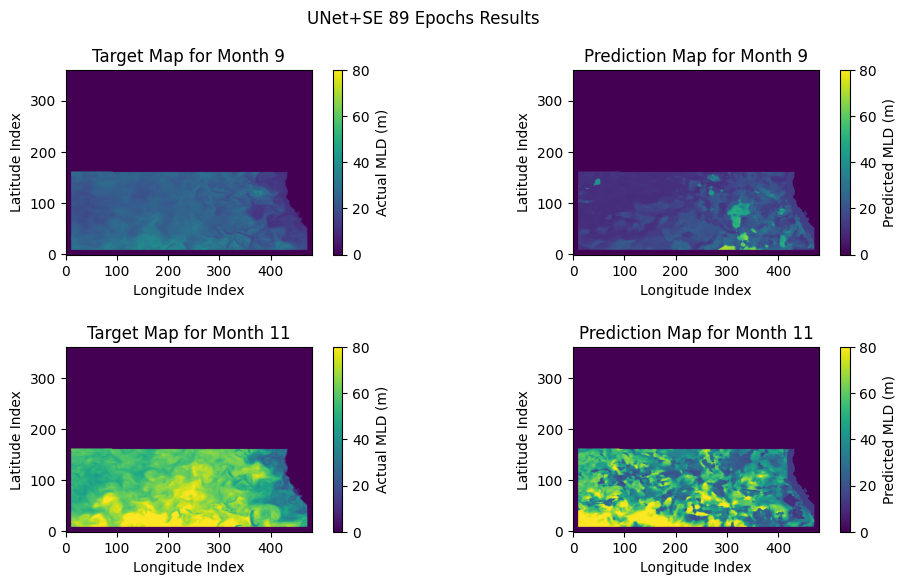

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(months), 2, figsize=(12, 6))
for i, month in enumerate(months):
    pred_map = pred_maps[i]
    label_map = label_maps[i]    
    im_0 = ax[i, 0].imshow(label_map, origin='lower', vmin=0, vmax=80, cmap='viridis')
    ax[i, 0].set_title('Target Map for Month ' + str(month))
    ax[i, 0].set_xlabel('Longitude Index')
    ax[i, 0].set_ylabel('Latitude Index')
    fig.colorbar(im_0, label='Actual MLD (m)', ax=ax[i, 0])
    im_1 = ax[i, 1].imshow(pred_map, origin='lower', vmin=0, vmax=80, cmap='viridis')
    ax[i, 1].set_title('Prediction Map for Month ' + str(month))
    ax[i, 1].set_xlabel('Longitude Index')
    ax[i, 1].set_ylabel('Latitude Index')
    fig.colorbar(im_1, label="Predicted MLD (m)", ax=ax[i, 1])
plt.suptitle("UNet+SE 89 Epochs Results")
plt.subplots_adjust(hspace=0.5)
plt.show()

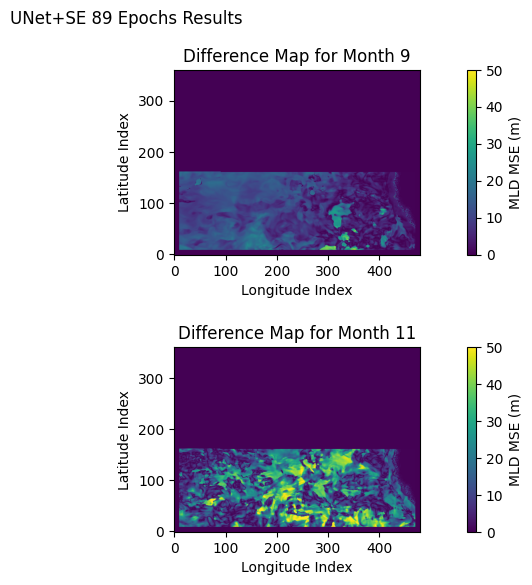

In [23]:
fig, ax = plt.subplots(len(months), 1, figsize=(12, 6))
for i, month in enumerate(months):
    if len(months) == 1:
        ax = [ax]  # Ensure ax is iterable if there's only one month
    pred_map = pred_maps[i]
    label_map = label_maps[i]    
    im_0 = ax[i].imshow(abs(label_map - pred_map), origin='lower', vmin=0, vmax=50, cmap='viridis')
    ax[i].set_title('Difference Map for Month ' + str(month))
    ax[i].set_xlabel('Longitude Index')
    ax[i].set_ylabel('Latitude Index')
    fig.colorbar(im_0, label='MLD MSE (m)', ax=ax[i])
plt.suptitle("UNet+SE 89 Epochs Results")
plt.subplots_adjust(hspace=0.5)
plt.show()